In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import SpaceTravLR 
import sys 
sys.path.append('/ix/djishnu/alw399/SpaceTravLR/src')

In [3]:
%matplotlib inline

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

In [4]:
import os 
training_dir = '/ix/djishnu/shared/djishnu_kor11/training_data_revision/tfh_network/mouse_lymph_slideseq_D5_1/chunk_0'
adata = sc.read_h5ad(os.path.join(training_dir, 'input_data/_adata.h5ad'))
adata

AnnData object with n_obs × n_vars = 12681 × 3354
    obs: 'celltype_label_tangram', 'cell_type', 'cell_type_int'
    uns: 'cell_thresholds', 'neighbors', 'received_ligands', 'received_ligands_tfl', 'umap'
    obsm: 'X_pca', 'X_spatial', 'X_umap', 'spatial', 'spatial_unscaled', 'tangram_ct_pred'
    varm: 'PCs'
    layers: 'imputed_count', 'normalized_count', 'raw_count'
    obsp: 'connectivities', 'distances'

In [5]:
adata.obs.cell_type.value_counts()

cell_type
B            6516
Resting T    2232
CD8+ T       1282
Tfh          1222
Treg         1012
Th2           282
DC            135
Name: count, dtype: int64

In [6]:
data = pd.DataFrame(adata.obs['cell_type'])
data['x'] = adata.obsm['spatial'][:, 0]
data['y'] = adata.obsm['spatial'][:, 1]

In [8]:
color_dict = {
    "B": "#74b854",
    "Resting T": "#6691ce",
    "Tfh": "#cb5364",
    "CD8+ T": "#c85d60",
    "Treg": "#929d3d",
    "Th2": "#ca783d",
    "DC": "#5d6cb1",
    'NK': '#9a43b5',
    'gd T': '#32a852'
}

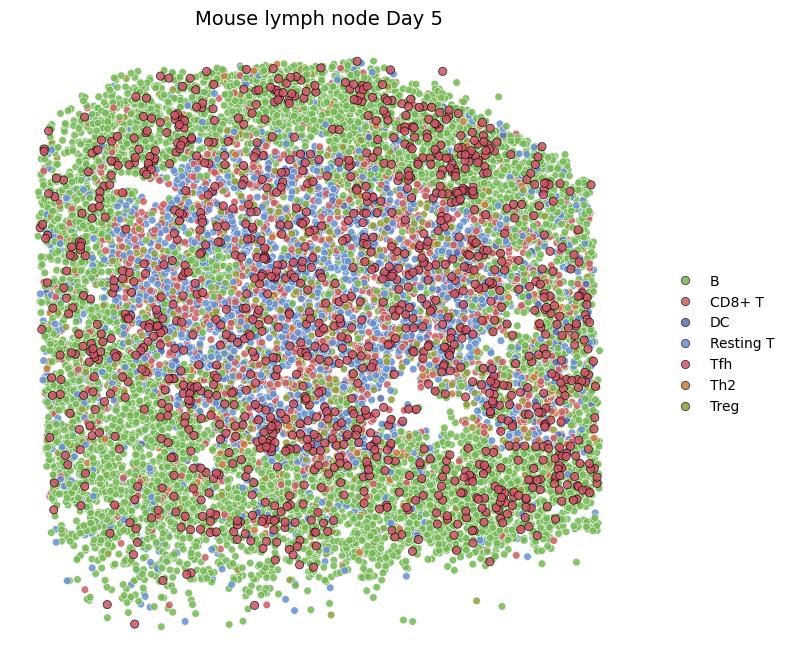

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=data[data['cell_type'] != 'Tfh'], 
    x='x', y='y', 
    hue='cell_type', 
    palette=color_dict, 
    s=30, ax=ax,
    alpha=0.85,
    legend=False
)
sns.scatterplot(
    data=data[data['cell_type'] == 'Tfh'], 
    x='x', y='y', 
    hue='cell_type', 
    palette=color_dict, 
    s=35, ax=ax,
    edgecolor='black', linewidth=0.5,
    alpha=0.85
)

ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), frameon=False)

ax.axis('off')
ax.set_title('Mouse lymph node Day 5', fontsize=14)
plt.tight_layout()
plt.tight_layout()
plt.gca().set_aspect('equal', 'box')
plt.savefig('figures/mouse_lymph_slideseq_D5_1_Tfh_spatial.svg', dpi=200, bbox_inches='tight', transparent=True, format='svg')
plt.show()

### Target screening

In [6]:
from SpaceTravLR.tools.network import RegulatoryFactory
from SpaceTravLR.gene_factory import GeneFactory

# gf = GeneFactory.from_json(adata, os.path.join(training_dir, 'betadata/run_params.json'))

In [7]:
# gf.load_betas(subsample=None, float16=True)

In [8]:
# Active ligands or receptors considered in model
adata.uns['cell_thresholds'].columns[adata.uns['cell_thresholds'].sum() != 0]

Index(['Sema3g', 'Sdc3', 'Angptl4', 'Selplg', 'Lifr', 'Ccl9', 'Nampt', 'Cdh4',
       'Fzd1', 'Itga2b',
       ...
       'Tslp', 'Dag1', 'Lif', 'Spn', 'Icam1', 'Il2rb', 'Ccr3', 'Cd274',
       'Fgf18', 'Notch2'],
      dtype='object', length=233)

In [25]:
###
# IMPORTANT: tfh_markers contains Il21 for the supplementary figures. Comment/uncomment which list of markers to use
###

# tfh_markers = ['Il21', 'Cxcr5', 'Pdcd1', 'Bcl6'] 
tfh_markers = ['Cxcr5', 'Pdcd1', 'Bcl6'] 

if 'Il21' in tfh_markers:
    suffix='_Il21'
else:
    suffix=''


tfh_markers = [x for x in tfh_markers if x in adata.var_names]
tfh_markers

['Cxcr5', 'Pdcd1', 'Bcl6']

In [26]:
from tqdm import tqdm

betadir = os.path.join(training_dir, 'betadata')
data = {}

for gene in tqdm(tfh_markers):

    betas = []

    if os.path.exists(os.path.join(betadir, gene + '_betadata.parquet')):
        betas.append(pd.read_parquet(os.path.join(betadir, gene + '_betadata.parquet')))
    
    if len(betas) > 0:
        data[gene] = pd.concat(betas)

In [27]:
data.keys()

dict_keys(['Cxcr5', 'Pdcd1', 'Bcl6'])

In [28]:
interactions = {}

for gene in tfh_markers:
    if gene in data:
        interactions[gene] = data[gene].loc[
            adata[adata.obs['cell_type'] == 'Tfh'].obs.index
        ]

In [29]:
network_genes = np.loadtxt('network_genes.txt', dtype=str)
len(network_genes)

290

In [30]:
extended_genes = np.loadtxt('extended_genes.txt', dtype=str)
len(extended_genes)

1187

In [31]:
scenic_genes = np.loadtxt('scenic_genes.txt', dtype=str)
scenic_genes = [g for g in scenic_genes if g in adata.var_names]
len(scenic_genes)

338

In [32]:
groom_genes = pd.read_csv('groom_tfhcore.csv')['Genes'].to_list()
groom_genes = [g for g in groom_genes if g in adata.var_names]
len(groom_genes) 

218

### Modulator interactions

In [33]:
dfr = pd.concat([interactions[gene] for gene in tfh_markers], axis=1)
dfr = dfr.groupby(dfr.columns, axis=1).sum()
dfr.columns = dfr.columns.str.replace('beta_', '')
dfr.drop('beta0', axis=1, inplace=True)
dfr.head(2)

,Atf3,Atf5,Atf6b,Bach2,Batf,Bcl11a,Bcl6b,Cebpb,Creb1,Creb3l3,...,Vezf1,Wt1,Yy1,Zbtb17,Zbtb33,Zeb1,Zfp148,Zfp281,Zfx,Zscan22
CGTAGTGACTTTAC,-0.002314,-0.000487,0.040654,0.004920,0.046928,-0.011853,-0.016751,0.065253,0.067092,0.0,...,-0.006000,0.0,0.127351,0.014913,0.094942,-0.090429,0.088296,0.008571,-0.005175,0.017380
GGCAACACGTAATC,-0.002376,-0.000477,0.041268,0.005083,0.046858,-0.012613,-0.016806,0.066984,0.067648,0.0,...,-0.006164,0.0,0.128580,0.014901,0.095018,-0.090854,0.088707,0.008738,-0.005132,0.017375


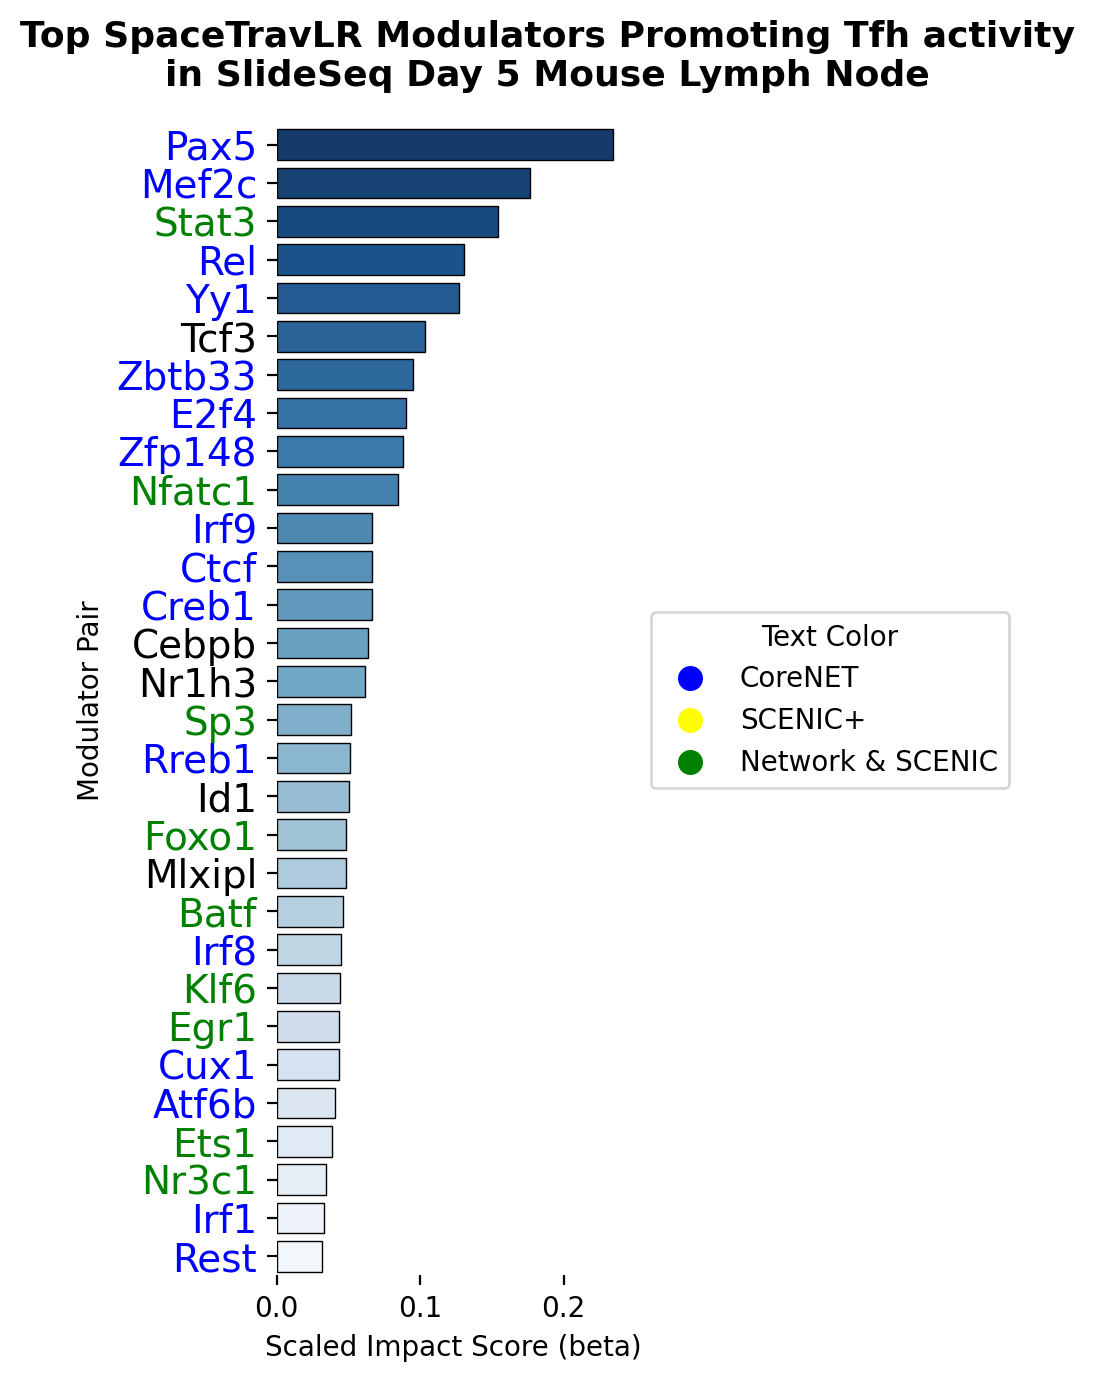

In [34]:
dfr_th2 = dfr.mean().sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(5, 7), dpi=200)

# Barplot for Th2
sns.barplot(
    x=dfr_th2.values, 
    y=dfr_th2.index, 
    ax=ax, 
    palette="Blues_r",
    linewidth=0.5,
    edgecolor='black'
)
ax.set_xlabel("Scaled Impact Score (beta)")
ax.set_ylabel("Modulator Pair")

for spine in ax.spines.values():
    spine.set_visible(False)

for label in ax.get_yticklabels():
    text = label.get_text()
    for gene in text.split('-'):
        if gene in network_genes and gene in scenic_genes:
            label.set_color('green')
        elif gene in network_genes:
            label.set_color('blue')
        elif gene in scenic_genes:
            label.set_color('yellow')
        
ax.tick_params(axis='y', labelsize=14)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], label='CoreNET', color='blue', lw=0, marker='o', markersize=8),
    Line2D([0], [0], label='SCENIC+', color='yellow', lw=0, marker='o', markersize=8),
    Line2D([0], [0], label='Network & SCENIC', color='green', lw=0, marker='o', markersize=8),
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), title="Text Color")

plt.suptitle(f"Top SpaceTravLR Modulators Promoting Tfh activity\nin SlideSeq Day 5 Mouse Lymph Node", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'figures/mouse_lymph_slideseq_D5_1_regulators{suffix}.svg', dpi=300, bbox_inches='tight', transparent=True, format='svg')
plt.show()

In [35]:
dfr_th2.to_csv(f'tables/mouse_lymph_slideseq_D5_1_regulators{suffix}.csv')

In [36]:
network_genes = set(network_genes)
scenic_genes = set(scenic_genes)
extended_genes= set(extended_genes)
groom_genes = set(groom_genes)
top_modulators = set(dfr_th2.index)
all_genes = set(adata.var_names)

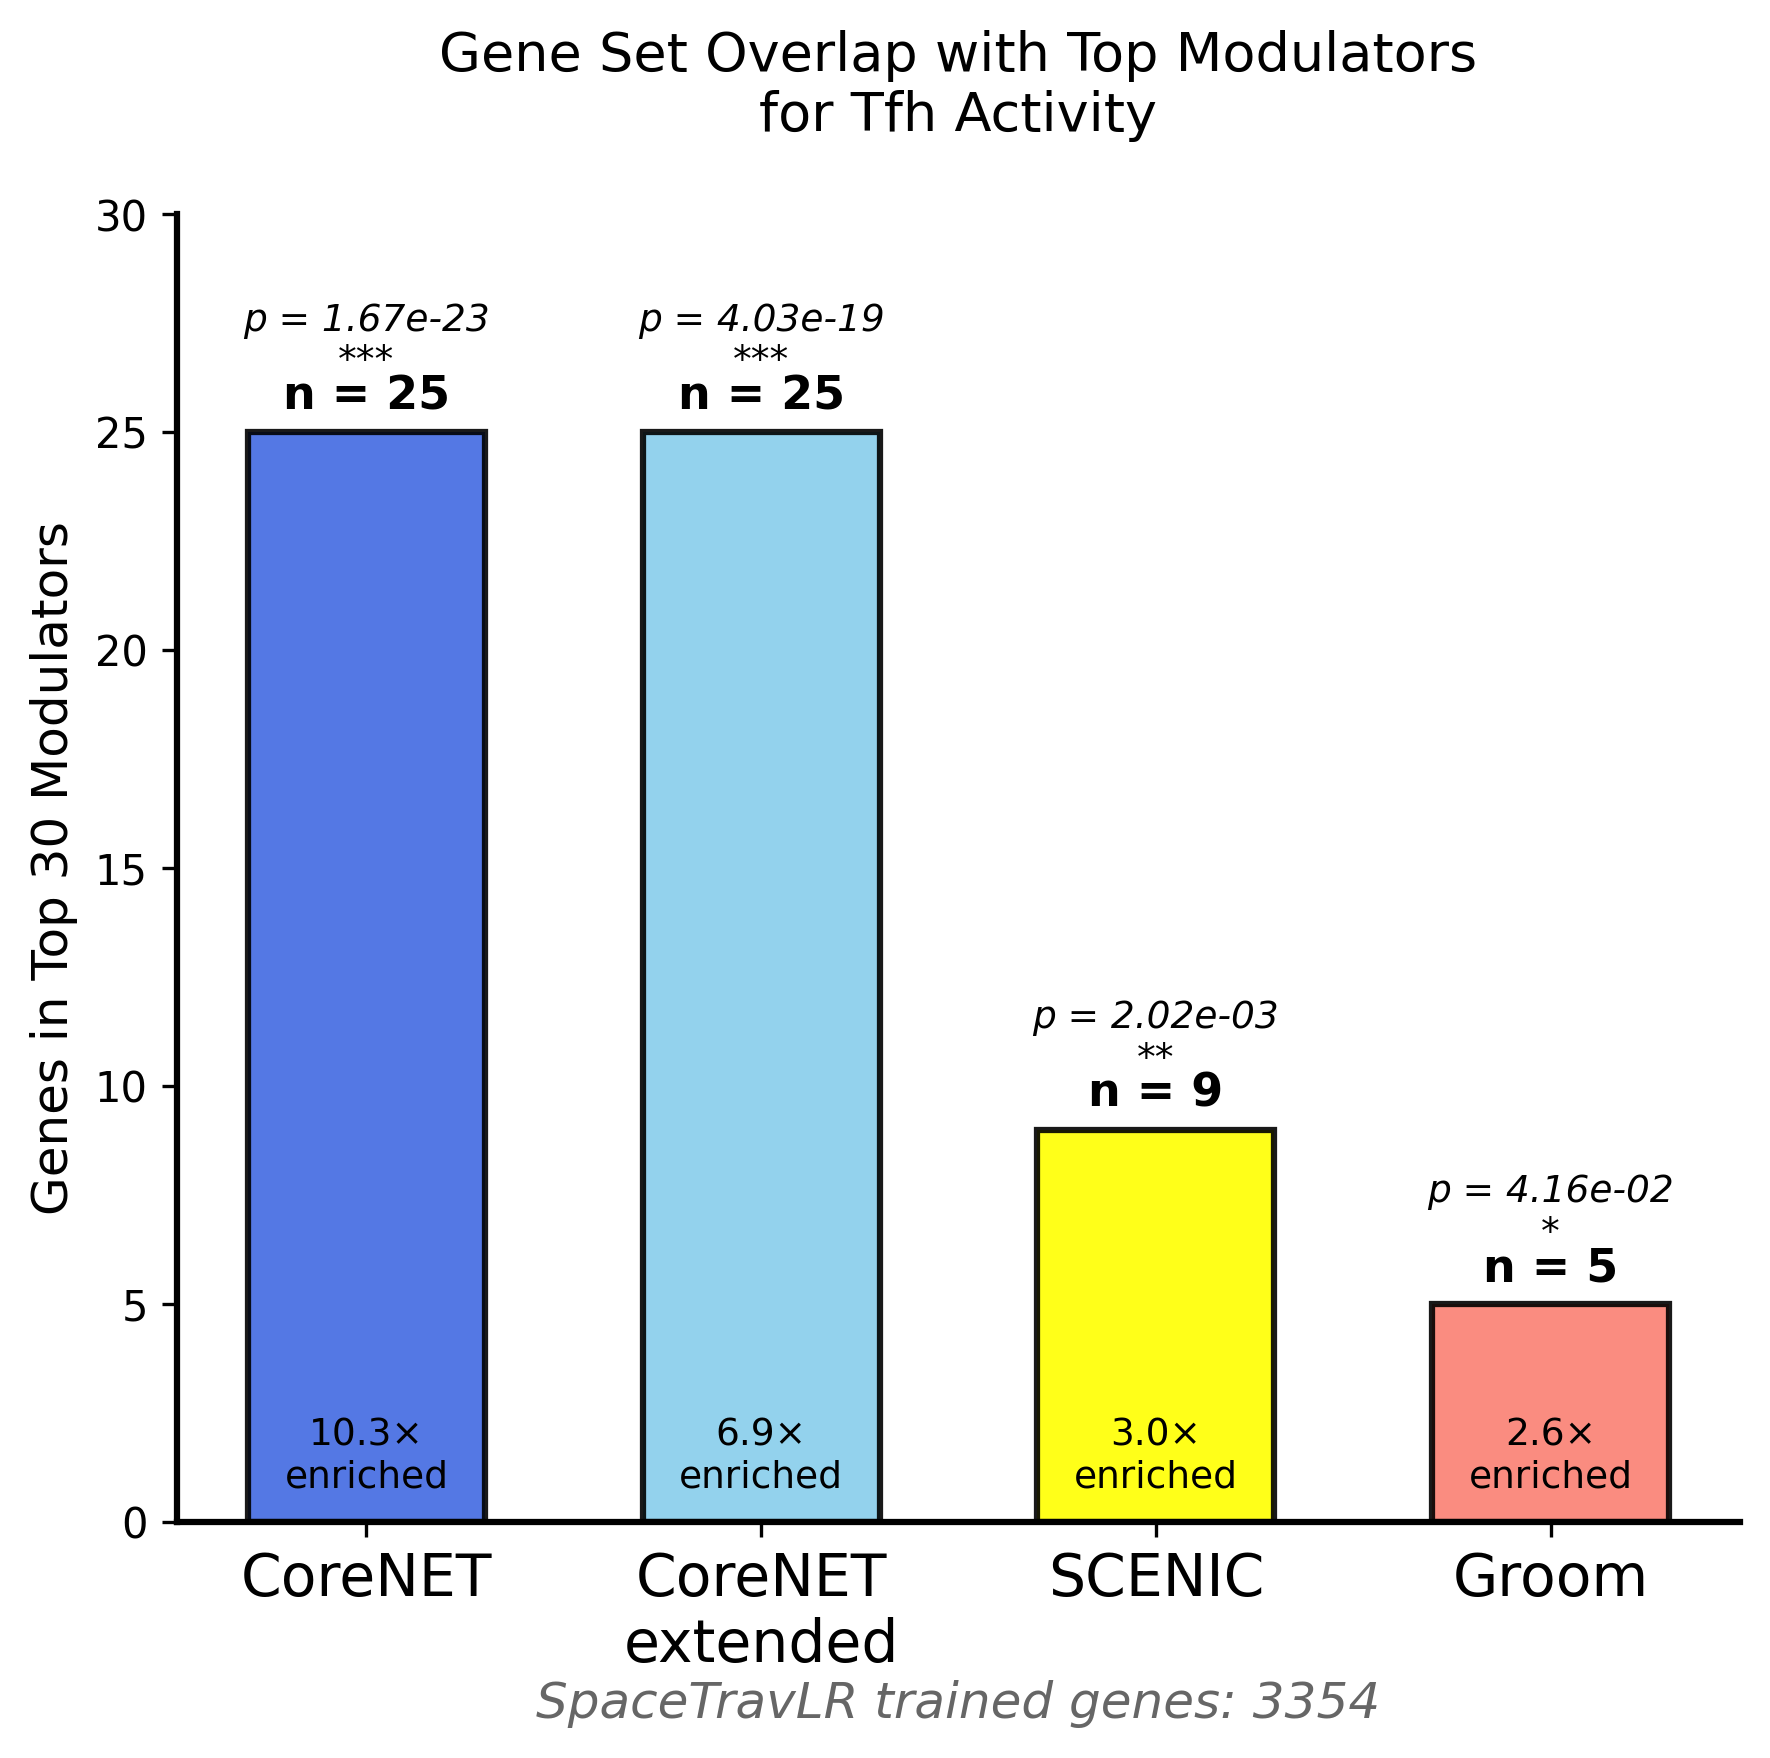

In [37]:
from scipy.stats import hypergeom
import matplotlib.pyplot as plt
import numpy as np

# Compute overlap sizes
N = len(all_genes)  # background/universe size
net_n = len(network_genes & all_genes)
extended_n = len(extended_genes & all_genes)
scenic_n = len(scenic_genes & all_genes)
groom_n = len(groom_genes & all_genes)
mod_n = len(top_modulators)

net_mod = len(network_genes & top_modulators)
extended_mod = len(extended_genes & top_modulators)
scenic_mod = len(scenic_genes & top_modulators)
groom_mod = len(groom_genes & top_modulators)

# Calculate p-values using hypergeometric test
pval_network = hypergeom.sf(net_mod - 1, N, net_n, mod_n)
pval_extended = hypergeom.sf(extended_mod - 1, N, extended_n, mod_n)
pval_scenic = hypergeom.sf(scenic_mod - 1, N, scenic_n, mod_n)
pval_groom = hypergeom.sf(groom_mod - 1, N, groom_n, mod_n)

# Calculate fold enrichment
fold_network = (net_mod / mod_n) / (net_n / N)
fold_extended = (extended_mod / mod_n) / (extended_n / N)
fold_scenic = (scenic_mod / mod_n) / (scenic_n / N)
fold_groom = (groom_mod / mod_n) / (groom_n / N)

# Create barplot
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

categories = ['CoreNET', 'CoreNET\nextended', 'SCENIC', 'Groom']
overlaps = [net_mod, extended_mod, scenic_mod, groom_mod]
pvalues = [pval_network, pval_extended, pval_scenic, pval_groom]
folds = [fold_network, fold_extended, fold_scenic, fold_groom]

bars = ax.bar(
    categories, overlaps, 
    color=['royalblue', 'skyblue', 'yellow', 'salmon'], 
    edgecolor='black', linewidth=1.5, width=0.6, alpha=0.9)

# Add value labels on bars
for i, (val, pval, fold) in enumerate(zip(overlaps, pvalues, folds)):
    # Number of genes
    ax.text(i, val + 0.3, f'n = {val}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')
    
    # Significance stars
    if pval < 0.001:
        sig_text = '***'
    elif pval < 0.01:
        sig_text = '**'
    elif pval < 0.05:
        sig_text = '*'
    else:
        sig_text = 'ns'
    
    # P-value and significance
    ax.text(i, val + 1.2, f'p = {pval:.2e}\n{sig_text}', 
            ha='center', va='bottom', fontsize=9, style='italic')
    
    # Fold enrichment at bottom
    ax.text(i, 1.5, f'{fold:.1f}×\nenriched', 
            ha='center', va='center', fontsize=9)

ax.set_ylabel('Genes in Top 30 Modulators', fontsize=12)
ax.set_title('Gene Set Overlap with Top Modulators\nfor Tfh Activity', 
             fontsize=13, pad=20)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.set_yticks(range(0, 31, 5))
ax.set_yticklabels([0, 5, 10, 15, 20, 25, 30])
ax.tick_params(axis='x', labelsize=14)

# Add subtitle with context
ax.text(0.5, -0.15, f'SpaceTravLR trained genes: {N}', 
        transform=ax.transAxes, ha='center', fontsize=12, style='italic', color='#666666')
        
plt.tight_layout()
plt.savefig(f'figures/mouse_lymph_slideseq_D5_1_hypergeom_barplot{suffix}.svg', 
            dpi=300, bbox_inches='tight', transparent=True, format='svg')
plt.show()

In [38]:
import pandas as pd

# 1. Create the DataFrame using the computed variables
df_overlap = pd.DataFrame({
    'Gene Set Name': ['CoreNET', 'CoreNET extended', 'SCENIC', 'Groom'],
    'Overlap Count (n)': [net_mod, extended_mod, scenic_mod, groom_mod],
    'Total Set Size (K)': [net_n, extended_n, scenic_n, groom_n],
    'Fold Enrichment': [fold_network, fold_extended, fold_scenic, fold_groom],
    'P-value': [pval_network, pval_extended, pval_scenic, pval_groom]
})

df_overlap.to_csv(f'tables/mouse_lymph_slideseq_D5_1_hypergeom_barplot{suffix}.csv')

In [39]:
df_overlap

,Gene Set Name,Overlap Count (n),Total Set Size (K),Fold Enrichment,P-value
0,CoreNET,25,271,10.313653,1.666767e-23
1,CoreNET extended,25,403,6.935484,4.028676e-19
2,SCENIC,9,338,2.976923,2.021505e-03
3,Groom,5,218,2.564220,4.161431e-02


In [40]:
N, net_n, extended_n, scenic_n, groom_n, mod_n

(3354, 271, 403, 338, 218, 30)